# CLIP: four applications in a few lines

**17 images · 17 supplied captions · one frozen model.** Use the same gallery for image → caption, text → images, image → images, and a before/after change.

In Colab, select **Runtime → Change runtime type → T4 GPU**, then **Run all**. CPU also works, but encoding is slower. The first run downloads OpenAI's ViT-B/32 weights (about 350 MB) and the small gallery. No API key or training is needed.

The saved outputs are a real CPU run of the original OpenAI model. GPU rounding can differ slightly, and these scores need not exactly match the lecture's quantized browser run. Change the query cells and rerun them to explore.

[Lecture](https://nipunbatra.github.io/attention/clip/) · [Image credits](https://nipunbatra.github.io/attention/clip/lab/CREDITS.md) · [OpenAI CLIP](https://github.com/openai/CLIP)

In [1]:
# Colab already provides PyTorch, Pillow and Matplotlib.
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/openai/CLIP.git@d05afc436d78f1c48dc0dbf8e5980a9d471f35f6"])

## 1. Load the small database
These are the lecture's photographs and labelled generated examples. Each record has an image, a display name and one supplied caption. Several captions may describe the same image well; the diagonal is not the only valid match.

In [2]:
import json, math, textwrap, zipfile
from pathlib import Path
from urllib.request import urlretrieve
import torch, clip
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

a = Path("clip-mini-gallery.zip")
if not a.exists():
    urlretrieve("https://nipunbatra.github.io/attention/clip/lab/clip-mini-gallery.zip", a)
with zipfile.ZipFile(a) as z:
    z.extractall(".")
root = Path("clip-mini-gallery")
records = json.loads((root / "manifest.json").read_text())
images = [Image.open(root / r["file"]).convert("RGB") for r in records]
captions = [r["caption"] for r in records]
ids = {r["id"]: i for i, r in enumerate(records)}
print(len(images), "images;", len(captions), "captions")

17 images; 17 captions


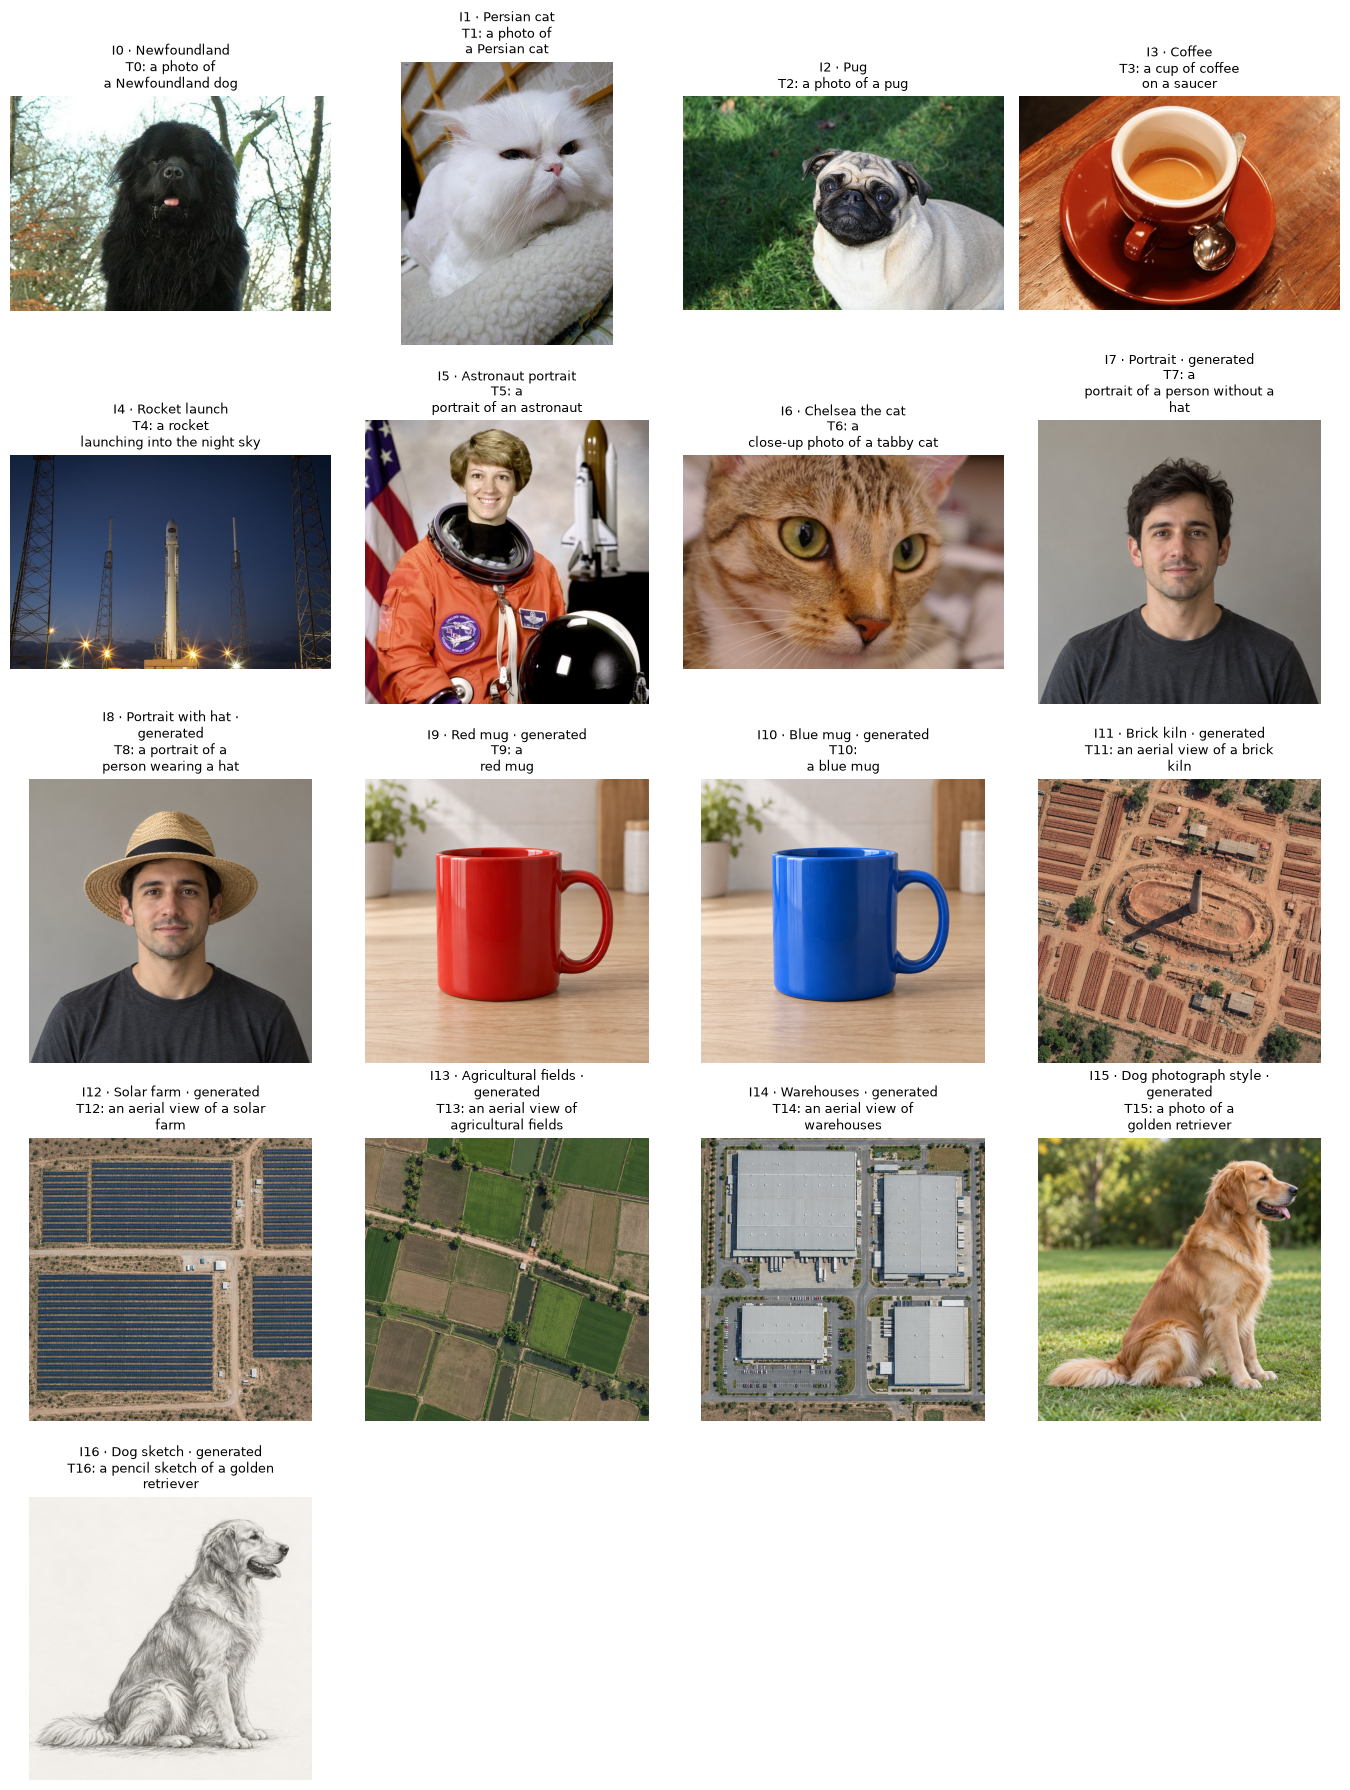

In [3]:
# A display helper only; the CLIP calculations stay in the cells below.
def show_images(indices, scores=None):
    indices = [int(i) for i in indices]
    cols = min(4, len(indices))
    fig, axes = plt.subplots(math.ceil(len(indices)/cols), cols,
                             figsize=(3.4*cols, 3.6*math.ceil(len(indices)/cols)), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, i in zip(axes.flat, indices):
        ax.imshow(images[i])
        label = f"I{i} · {records[i]['title']}"
        label += f"\ncosine {float(scores[i]):+.3f}" if scores is not None else f"\nT{i}: {captions[i]}"
        ax.set_title(textwrap.fill(label, 32, replace_whitespace=False), fontsize=9)
    plt.tight_layout(); plt.show()

show_images(range(len(images)))

## 2. What goes into each encoder?
`preprocess` resizes/crops and normalizes RGB pixels. `tokenize` turns our captions into token IDs, with start/end tokens and padding to 77 positions. Filenames and gallery titles are never model inputs.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
x = torch.stack([preprocess(im) for im in images]).to(device)
tokens = clip.tokenize(captions).to(device)
print("Device:", device)
print("Images:", tuple(x.shape), "= [images, RGB channels, height, width]")
print("Text:", tuple(tokens.shape), "= [captions, token positions]")
print("First caption:", captions[0])
print("Its first 12 token IDs:", tokens[0, :12].tolist())

Device: cpu
Images: (17, 3, 224, 224) = [images, RGB channels, height, width]
Text: (17, 77) = [captions, token positions]
First caption: a photo of a Newfoundland dog
Its first 12 token IDs: [49406, 320, 1125, 539, 320, 28079, 1929, 49407, 0, 0, 0, 0]


## 3. Encode once, then normalize
`encode_image` and `encode_text` include their learned projections. Each output has 512 coordinates. Divide **each row** by its own length so a dot product becomes a cosine. The encoders' weights stay fixed throughout this lab.

In [5]:
with torch.inference_mode():
    z_image = model.encode_image(x).float()
    z_text = model.encode_text(tokens).float()
U = F.normalize(z_image, dim=-1)  # one unit image vector per row
V = F.normalize(z_text, dim=-1)   # one unit text vector per row
print("Before normalization:", tuple(z_image.shape), tuple(z_text.shape))
print("After normalization, U and V:", tuple(U.shape), tuple(V.shape))
print("First image: raw first 6 coordinates:", z_image[0, :6].cpu().numpy().round(3))
print("First image: unit first 6 coordinates:", U[0, :6].cpu().numpy().round(3))
print("First caption: unit first 6 coordinates:", V[0, :6].cpu().numpy().round(3))
print("First 3 image-vector lengths:", U[:3].norm(dim=-1).cpu().numpy())

Before normalization: (17, 512) (17, 512)
After normalization, U and V: (17, 512) (17, 512)
First image: raw first 6 coordinates: [ 0.416  0.288 -0.279  0.267  0.478 -0.669]
First image: unit first 6 coordinates: [ 0.037  0.026 -0.025  0.024  0.043 -0.06 ]
First caption: unit first 6 coordinates: [ 0.057  0.012 -0.059  0.026  0.003 -0.055]
First 3 image-vector lengths: [1.        1.0000001 0.9999998]


## 4. One matrix contains every image–caption comparison
`U @ V.T` has **image rows** and **caption columns**. Entry `[i, j]` compares image `Ii` with caption `Tj`. These are raw cosines, not probabilities. We do not need temperature or softmax just to rank candidates.

[17, 512] @ [512, 17] → (17, 17)
C[0, 0] = 0.35540682077407837
Same value from one dot product = 0.35540682077407837


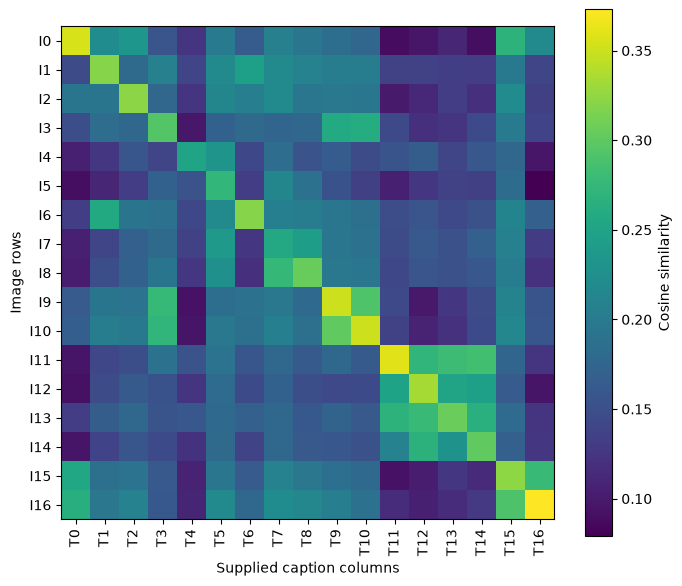

In [6]:
C = U @ V.T
print("[17, 512] @ [512, 17] →", tuple(C.shape))
print("C[0, 0] =", C[0, 0].item())
print("Same value from one dot product =", torch.dot(U[0], V[0]).item())
plt.figure(figsize=(7, 6))
plt.imshow(C.cpu(), cmap="viridis")
plt.xticks(range(17), [f"T{i}" for i in range(17)], rotation=90)
plt.yticks(range(17), [f"I{i}" for i in range(17)])
plt.xlabel("Supplied caption columns"); plt.ylabel("Image rows")
plt.colorbar(label="Cosine similarity"); plt.tight_layout(); plt.show()

## 5. Given an image, find its closest captions
Pick one **row** of `C`. CLIP ranks our captions; it does not write a new caption. Try `rocket`, `red-mug`, or `retriever-sketch`.

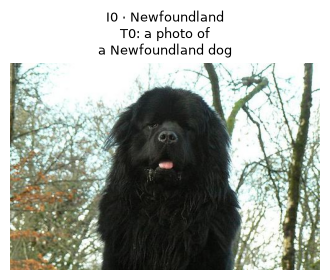

Caption scores: (17,)
T 0  +0.355  a photo of a Newfoundland dog
T15  +0.269  a photo of a golden retriever
T 2  +0.233  a photo of a pug
T 1  +0.222  a photo of a Persian cat
T16  +0.219  a pencil sketch of a golden retriever


In [7]:
image_id = "newfoundland"  # change this
q = ids[image_id]
show_images([q])
scores = C[q]  # shape [17]: this image against every caption
print("Caption scores:", tuple(scores.shape))
for j in scores.argsort(descending=True)[:5].tolist():
    print(f"T{j:2d}  {scores[j].item():+.3f}  {captions[j]}")

## 6. Given words, find images
We can supply a new query that was never in the original caption list. Encode it with the same text encoder and compare it with every cached image vector. Try `something to drink`, `a pet`, or `solar panels`.

[17, 512] @ (512, 1) → 17 image scores
Query: something to drink


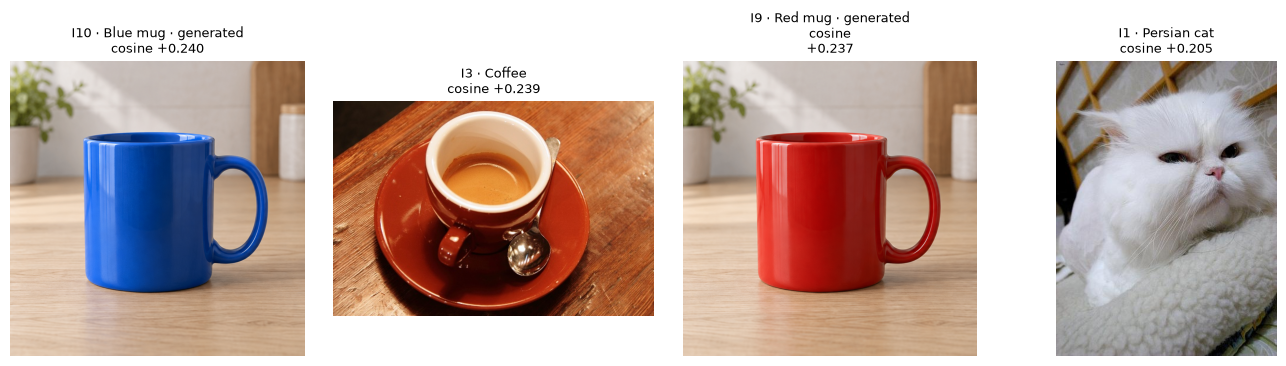

In [8]:
query = "something to drink"  # change this
with torch.inference_mode():
    z_query = model.encode_text(clip.tokenize([query]).to(device)).float()
v_query = F.normalize(z_query, dim=-1)
scores = (U @ v_query.T).squeeze(1)
print("[17, 512] @", tuple(v_query.T.shape), "→ 17 image scores")
print("Query:", query)
show_images(scores.argsort(descending=True)[:4].tolist(), scores)

## 7. Given an image, find similar images
This uses only image vectors. Exclude the query itself: its cosine with itself is approximately 1. Try the Persian cat, the red mug, or the generated dog photograph.

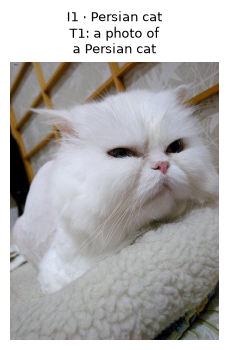

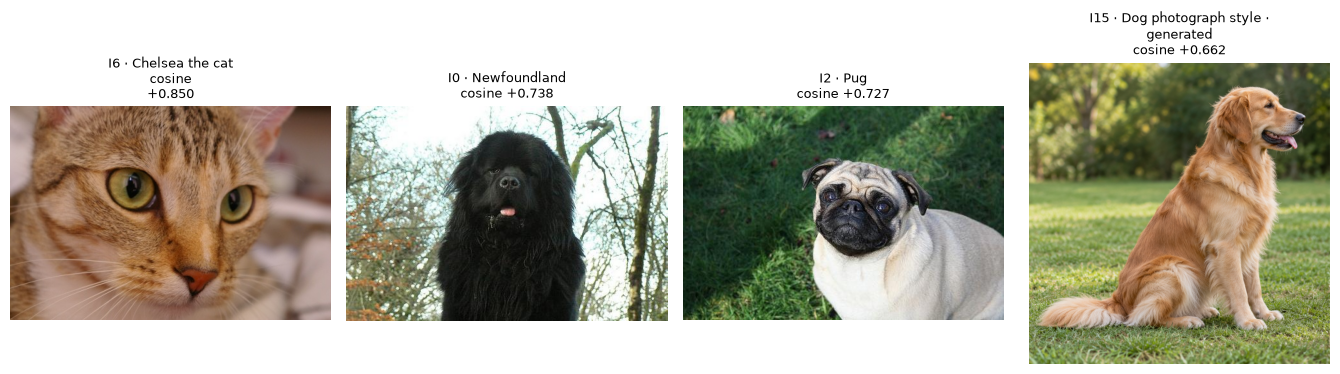

In [9]:
image_id = "Persian"  # try "red-mug" or "retriever-photo"
q = ids[image_id]
show_images([q])
scores = U @ U[q]  # [17, 512] @ [512] → [17]
scores[q] = -torch.inf  # do not retrieve the query itself
show_images(scores.argsort(descending=True)[:4].tolist(), scores)

## 8. Which words line up with a change?
Show both images first. Subtract **after − before**, using their unit image vectors, and normalize the difference again. Compare that direction with supplied candidate words.

The edited pictures already exist: CLIP neither creates the edit nor generates its explanation. Other changes in the pair can influence the ranking.

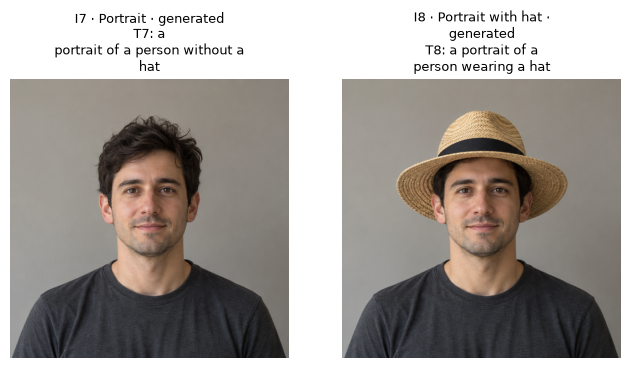

Difference shape: (512,) length: 0.34263354539871216
Normalized difference length: 1.0
[4, 512] @ [512] → (4,)
hat      +0.1865
boat     +0.0281
cup      +0.0134
cat      -0.0113


In [10]:
before_id, after_id = "portrait", "portrait-hat"
words = ["hat", "boat", "cup", "cat"]
before, after = ids[before_id], ids[after_id]
show_images([before, after])
delta = U[after] - U[before]
length = delta.norm()
if length < 1e-6:
    raise ValueError("The two images have no stable change direction.")
d = delta / length
with torch.inference_mode():
    W = F.normalize(model.encode_text(clip.tokenize(words).to(device)).float(), dim=-1)
change_scores = W @ d
print("Difference shape:", tuple(delta.shape), "length:", length.item())
print("Normalized difference length:", d.norm().item())
print("[4, 512] @ [512] →", tuple(change_scores.shape))
for j in change_scores.argsort(descending=True).tolist():
    print(f"{words[j]:8s} {change_scores[j].item():+.4f}")

### Two quick checks, then try another pair
Reversing the edit negates the scores. Changing the candidate words changes what the ranking can tell us.

- Red to blue: `red-mug`, `blue-mug`; words `['blue', 'red', 'cup', 'hat']`.
- Photo to sketch: `retriever-photo`, `retriever-sketch`; words `['pencil sketch', 'photograph', 'dog', 'cat']`.
- Reverse either pair. Which scores switch sign?
- Give the dog image a caption menu with no dogs. Why does the top answer still not prove it is correct?

In [11]:
reverse_scores = W @ (-d)
print("Reverse direction:", {word: round(score, 4) for word, score in zip(words, reverse_scores.tolist())})
print("Reversal check:", torch.allclose(reverse_scores, -change_scores, atol=1e-6))
print("All gallery vectors have unit length:",
      torch.allclose(U.norm(dim=1), torch.ones(len(images), device=device), atol=1e-5))

Reverse direction: {'hat': -0.1865, 'boat': -0.0281, 'cup': -0.0134, 'cat': 0.0113}
Reversal check: True
All gallery vectors have unit length: True


## What stayed the same?
All four applications reused the same frozen encoders and cached gallery vectors. We changed only the query and the dot product. Similarity is a ranking signal within these choices, not a guarantee about what an image contains.

To run locally: install `torch torchvision matplotlib Pillow` and the pinned OpenAI CLIP package from the setup cell, then run this notebook with a Python 3 kernel. The saved reference run used Python 3.12 and PyTorch 2.13 on CPU.